<a href="https://colab.research.google.com/github/wathsan11/ML-grape-berries-hyperspectral-/blob/main/GrapeBerriesHyperspectral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 45

##About the GrapeBerries Huperspectural Images Dataset

In [85]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/grapes.csv", sep=";")    # Load the 'grapes.csv' file into a pandas DataFrame, specifying semicolon as the separator
display(df.head())

,Unnamed: 0,Variety,Sugar content (g/l),x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
0,1,SYRAH,144.738,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,...,0.305829,0.312961,0.315948,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379
1,2,SYRAH,163.251,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,...,0.314022,0.315759,0.321164,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064
2,3,SYRAH,178.398,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,...,0.333914,0.339243,0.340825,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477
3,4,SYRAH,193.545,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,...,0.326189,0.329614,0.334720,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181
4,5,SYRAH,156.519,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,...,0.317075,0.322848,0.324559,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115


In [4]:
df.shape

(274, 207)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Columns: 207 entries, Unnamed: 0 to x.1003.5
dtypes: float64(205), int64(1), object(1)
memory usage: 443.2+ KB


In [6]:
variety = df.Variety
sugarContent = df['Sugar content (g/l)']

In [7]:
print(variety)

0      SYRAH
1      SYRAH
2      SYRAH
3      SYRAH
4      SYRAH
       ...  
269      FER
270      FER
271      FER
272      FER
273      FER
Name: Variety, Length: 274, dtype: object


**Suger Content vs Varity**<br>
There are 3 graph berries types (SYRAH, MAUZAC, FER)

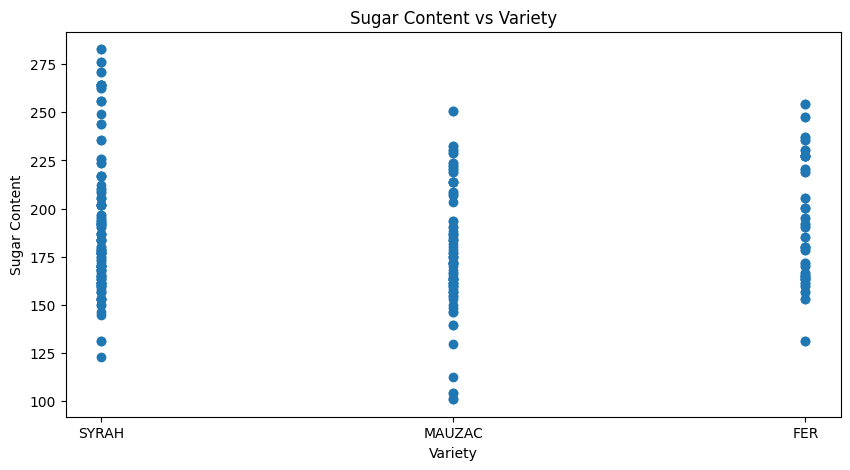

In [8]:
fig1 = plt.figure(figsize=(10,5))
plt.scatter(variety,sugarContent)
plt.ylabel("Sugar Content")
plt.xlabel("Variety")
plt.title("Sugar Content vs Variety")
plt.show()

Quantity of each variety as a pie chart

In [9]:
quantities = df['Variety'].value_counts()
print(quantities)

Variety
SYRAH     126
MAUZAC     85
FER        63
Name: count, dtype: int64


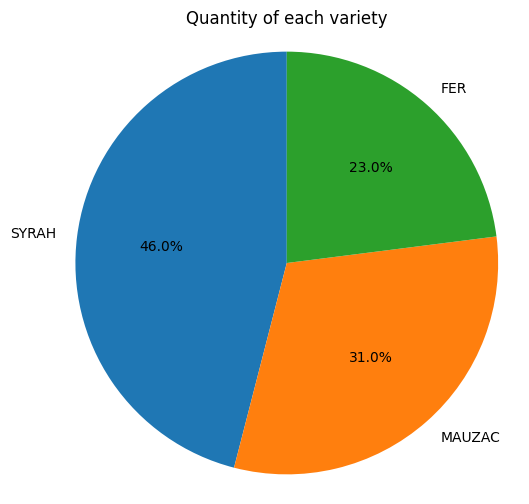

In [10]:
fig2 = plt.figure(figsize=(6,6))
plt.pie(quantities, labels= quantities.index, autopct='%1.1f%%',startangle=90,shadow=False)
plt.axis('equal')
plt.title("Quantity of each variety")
plt.show()

Wavelengths

In [11]:
imgLength_columns_df = df.filter(regex=r'^x\.')
display(imgLength_columns_df.head())

,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,x.423.29,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
0,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,0.074226,0.070202,0.066113,...,0.305829,0.312961,0.315948,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379
1,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,0.072666,0.068645,0.064228,...,0.314022,0.315759,0.321164,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064
2,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,0.080265,0.076254,0.072553,...,0.333914,0.339243,0.340825,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477
3,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,0.081407,0.077536,0.073961,...,0.326189,0.329614,0.334720,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181
4,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,0.076906,0.072377,0.068974,...,0.317075,0.322848,0.324559,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115


In [12]:
imgLength_columns_df.describe()

,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,x.423.29,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
count,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,...,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000
mean,0.147450,0.126824,0.113056,0.103056,0.095712,0.089099,0.083551,0.078915,0.074883,0.071322,...,0.337773,0.339957,0.342534,0.347161,0.352931,0.359201,0.367682,0.376219,0.385542,0.354093
std,0.009274,0.008172,0.007735,0.007498,0.007322,0.007222,0.007100,0.007037,0.007012,0.006902,...,0.024806,0.024788,0.024987,0.025082,0.025484,0.025685,0.026270,0.026842,0.027109,0.022379
min,0.125258,0.104410,0.093144,0.083413,0.076369,0.070179,0.065280,0.061012,0.057939,0.054886,...,0.283710,0.286194,0.288008,0.294671,0.299517,0.305934,0.311395,0.321888,0.327541,0.308980
25%,0.142021,0.122035,0.108329,0.098554,0.091625,0.084906,0.079497,0.074697,0.070772,0.067134,...,0.318309,0.321428,0.322925,0.328132,0.333237,0.340242,0.348174,0.355489,0.365295,0.336077
50%,0.147429,0.126872,0.113127,0.103141,0.095519,0.088523,0.082944,0.078278,0.074225,0.070513,...,0.337588,0.339892,0.341410,0.346318,0.352364,0.359773,0.366964,0.375281,0.385303,0.352462
75%,0.152870,0.130762,0.116908,0.107201,0.099601,0.092887,0.087379,0.082624,0.078324,0.074677,...,0.356335,0.358440,0.361054,0.366368,0.370812,0.376287,0.386984,0.394249,0.405046,0.369167
max,0.187758,0.165932,0.151804,0.140971,0.131698,0.124344,0.119093,0.112938,0.108828,0.104071,...,0.426330,0.432944,0.434410,0.443655,0.452067,0.460728,0.466456,0.481884,0.488991,0.441394


**Sugar Content vs imgValue (x.397.32)**

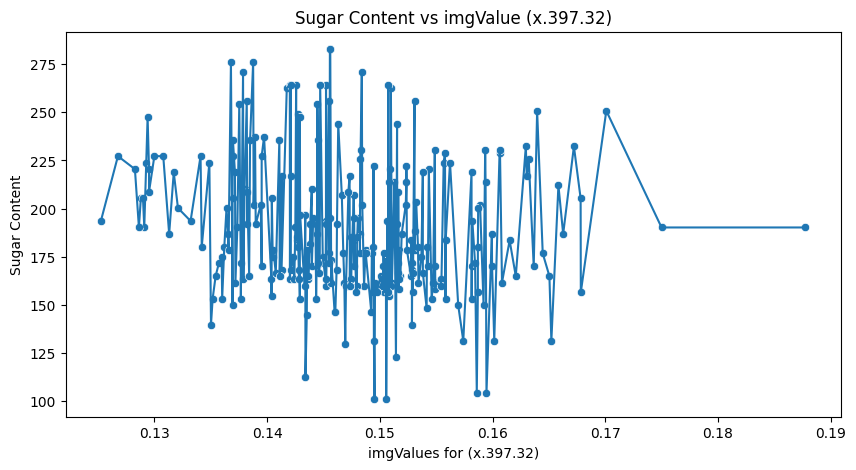

In [13]:
fig3 = plt.figure(figsize=(10,5))
sns.lineplot(x="x.397.32", y="Sugar content (g/l)", data=df)
sns.scatterplot(x="x.397.32", y="Sugar content (g/l)", data=df)
plt.title("Sugar Content vs imgValue (x.397.32)")
plt.xlabel("imgValues for (x.397.32)")
plt.ylabel("Sugar Content")
plt.show()

**Sugar Content vs imgValue (x.397.32) only SYRAH**

In [14]:
df_syrah = df[df['Variety'] == 'SYRAH']
display(df_syrah.head())

,Unnamed: 0,Variety,Sugar content (g/l),x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
0,1,SYRAH,144.738,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,...,0.305829,0.312961,0.315948,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379
1,2,SYRAH,163.251,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,...,0.314022,0.315759,0.321164,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064
2,3,SYRAH,178.398,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,...,0.333914,0.339243,0.340825,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477
3,4,SYRAH,193.545,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,...,0.326189,0.329614,0.334720,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181
4,5,SYRAH,156.519,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,...,0.317075,0.322848,0.324559,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115


In [15]:
df_syrah.shape

(126, 207)

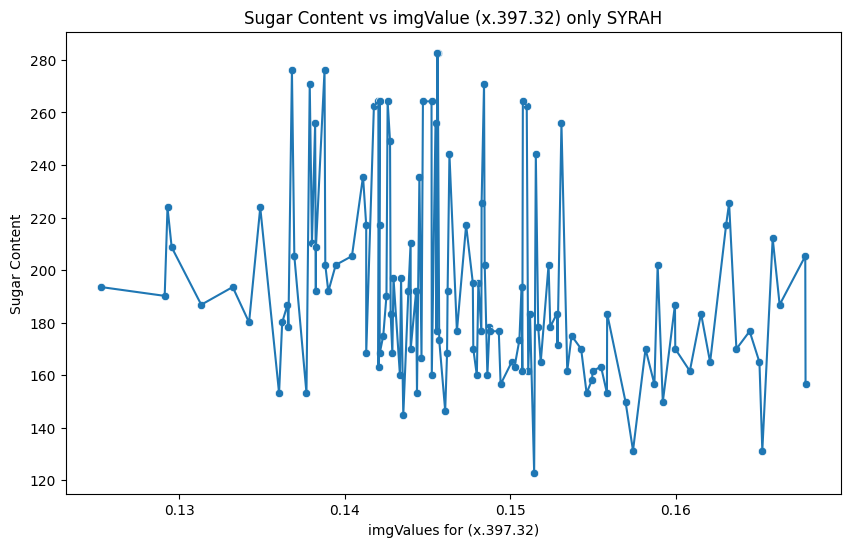

In [16]:
fig4=plt.figure(figsize=(10, 6))
sns.lineplot(x="x.397.32", y="Sugar content (g/l)", data=df_syrah)
sns.scatterplot(x="x.397.32", y="Sugar content (g/l)", data=df_syrah)
plt.title("Sugar Content vs imgValue (x.397.32) only SYRAH")
plt.xlabel("imgValues for (x.397.32)")
plt.ylabel("Sugar Content")
plt.show()

Sugar Content vs imgValue (x.397.32) only MAUZAC

In [17]:
df_MAUZAC = df[df['Variety']=='MAUZAC']
df_MAUZAC.head()

,Unnamed: 0,Variety,Sugar content (g/l),x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
70,71,MAUZAC,203.643,0.153229,0.129270,0.113893,0.103352,0.097116,0.090665,0.085803,...,0.318115,0.321281,0.322143,0.329922,0.336186,0.342872,0.347483,0.358873,0.365303,0.336834
71,72,MAUZAC,185.130,0.147404,0.125345,0.111601,0.102222,0.094935,0.088448,0.083026,...,0.286323,0.288257,0.292519,0.295599,0.301523,0.307624,0.311395,0.322760,0.327541,0.311135
72,73,MAUZAC,169.983,0.154910,0.132844,0.119273,0.109452,0.101267,0.094224,0.088931,...,0.314579,0.313485,0.318355,0.321357,0.328117,0.334484,0.342250,0.348868,0.361682,0.335813
73,74,MAUZAC,148.104,0.154157,0.130793,0.114626,0.103291,0.095695,0.088858,0.082930,...,0.319778,0.323670,0.324927,0.331022,0.333361,0.340341,0.348941,0.360666,0.368063,0.343448
74,75,MAUZAC,188.496,0.153136,0.129781,0.115489,0.103918,0.096806,0.090061,0.084470,...,0.321555,0.324426,0.326343,0.327932,0.333239,0.340568,0.348548,0.353602,0.364910,0.339246


In [18]:
df_MAUZAC.shape

(85, 207)

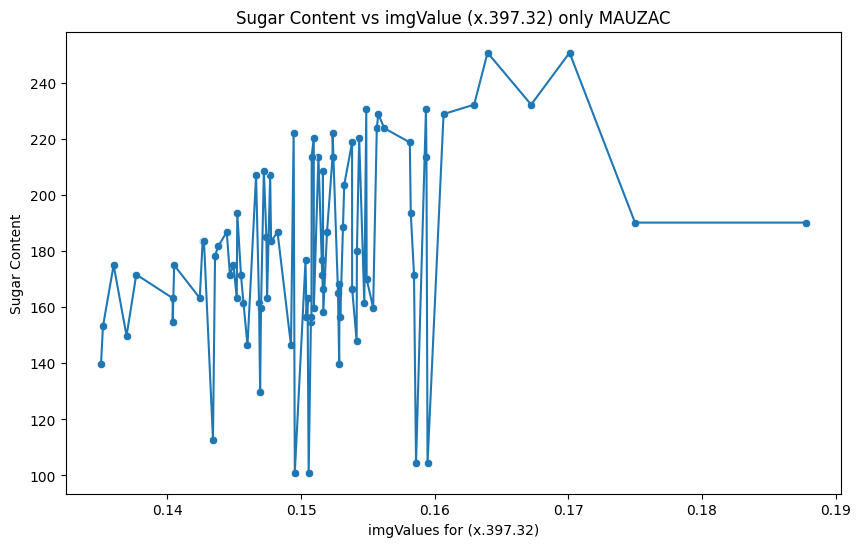

In [19]:
fig5 = plt.figure(figsize=(10, 6))
sns.lineplot(x='x.397.32', y='Sugar content (g/l)', data=df_MAUZAC)
sns.scatterplot(x='x.397.32', y='Sugar content (g/l)', data=df_MAUZAC)
plt.title("Sugar Content vs imgValue (x.397.32) only MAUZAC")
plt.xlabel("imgValues for (x.397.32)")
plt.ylabel("Sugar Content")
plt.show()

Sugar Content vs imgValue (x.397.32) only FER

In [20]:
df_FER = df[df['Variety']=='FER']
df_FER.head()

,Unnamed: 0,Variety,Sugar content (g/l),x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
161,162,FER,131.274,0.149477,0.127806,0.113721,0.102793,0.095053,0.088501,0.081813,...,0.356474,0.357845,0.360900,0.367900,0.376492,0.379142,0.388099,0.404356,0.407416,0.375337
162,163,FER,131.274,0.160154,0.137597,0.122966,0.111622,0.103890,0.097191,0.090906,...,0.382279,0.388751,0.391206,0.391123,0.400883,0.409618,0.417756,0.426123,0.438271,0.406831
163,164,FER,163.251,0.142831,0.122988,0.108052,0.099165,0.092472,0.085898,0.079561,...,0.354108,0.353966,0.356672,0.362960,0.366734,0.371562,0.383511,0.394413,0.404888,0.371900
164,165,FER,163.251,0.151677,0.130103,0.114106,0.104657,0.095697,0.088825,0.082654,...,0.366716,0.372479,0.372571,0.377115,0.385593,0.388876,0.402413,0.411726,0.423335,0.384827
165,166,FER,180.081,0.149373,0.128775,0.114152,0.104844,0.096981,0.089735,0.084408,...,0.345928,0.345948,0.348586,0.355770,0.357846,0.366516,0.379167,0.381852,0.392880,0.368129


In [21]:
df_FER.shape

(63, 207)

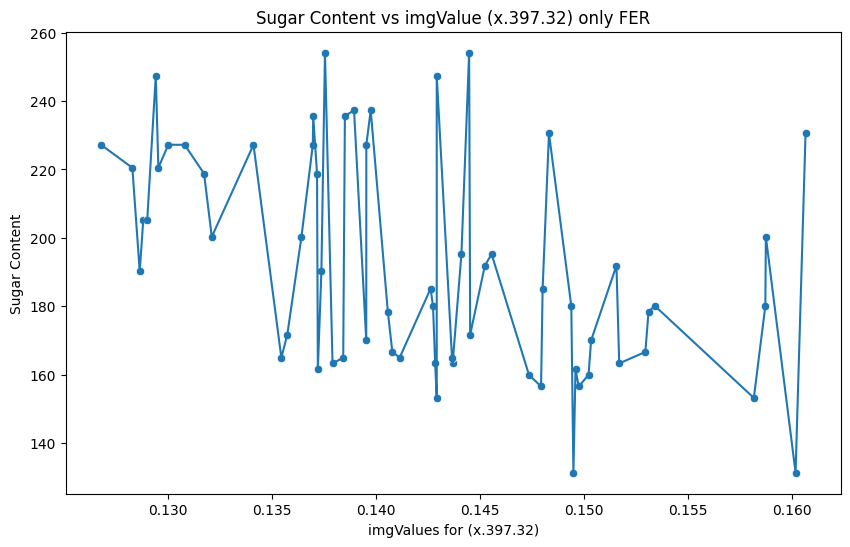

In [22]:
fig6 = plt.figure(figsize=(10, 6))
sns.lineplot(x='x.397.32', y='Sugar content (g/l)', data=df_FER)
sns.scatterplot(x='x.397.32', y='Sugar content (g/l)', data=df_FER)
plt.title("Sugar Content vs imgValue (x.397.32) only FER")
plt.xlabel("imgValues for (x.397.32)")
plt.ylabel("Sugar Content")
plt.show()

Sugar Content vs imgValue (x.397.32) for All Varieties

/tmp/ipykernel_5663/754325693.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_FER['Variety'] = 'FER'
/tmp/ipykernel_5663/754325693.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_MAUZAC['Variety'] = 'MAUZAC'
/tmp/ipykernel_5663/754325693.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

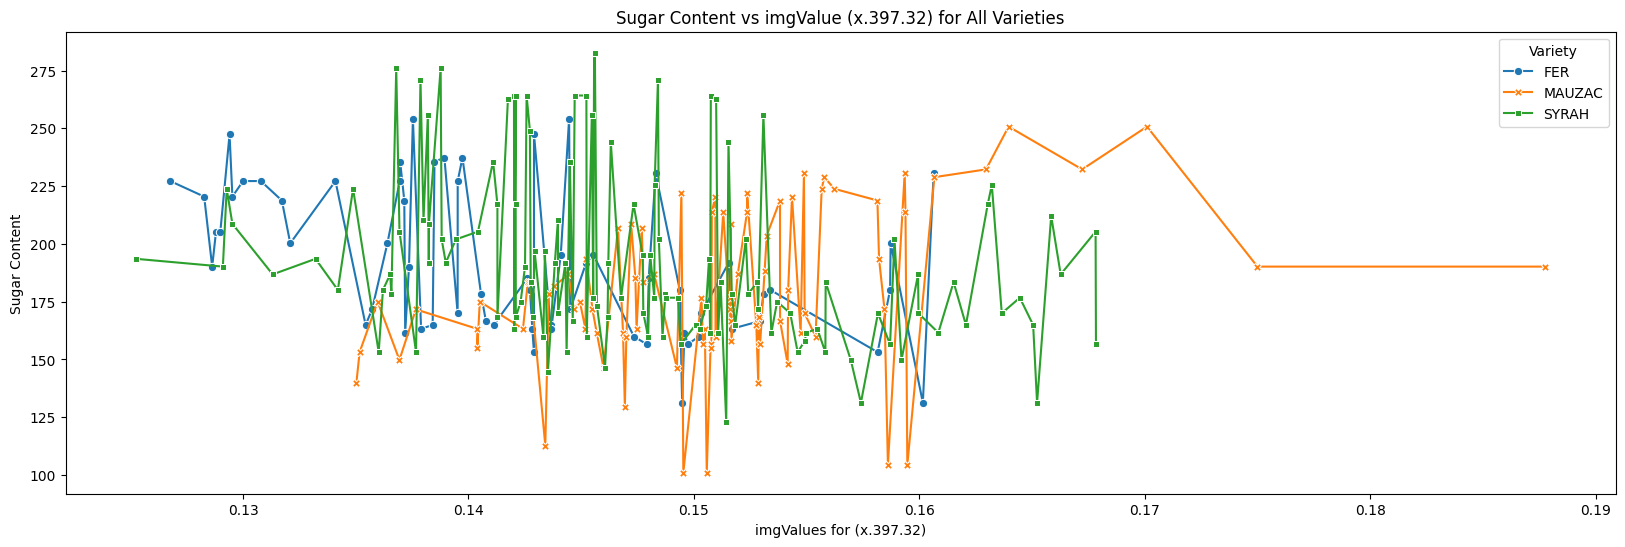

In [23]:
df_FER['Variety'] = 'FER'
df_MAUZAC['Variety'] = 'MAUZAC'
df_syrah['Variety'] = 'SYRAH'

df_all = pd.concat([df_FER, df_MAUZAC, df_syrah])

fig7 = plt.figure(figsize=(20,6))

# Lineplot with hue (color) and style (markers) for each variety
sns.lineplot(
    x='x.397.32',
    y='Sugar content (g/l)',
    hue='Variety',     # color by variety
    style='Variety',   # different marker styles
    markers=True,
    dashes=False,      # solid lines
    data=df_all
)

plt.title("Sugar Content vs imgValue (x.397.32) for All Varieties")
plt.xlabel("imgValues for (x.397.32)")
plt.ylabel("Sugar Content")
plt.legend(title='Variety')
plt.show()

Wavelength vs Intensity (Row 1)

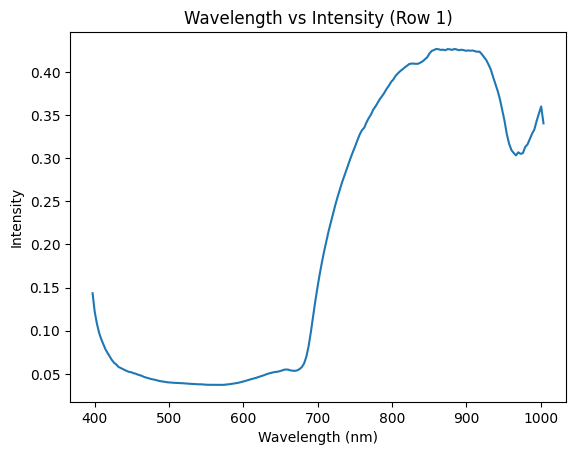

In [24]:
row1 = imgLength_columns_df.iloc[0].values

wavelengths = [float(col.replace('x.', '')) for col in imgLength_columns_df.columns]


plt.plot(wavelengths, row1)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Wavelength vs Intensity (Row 1)")
plt.show()



Wavelength vs Intensity (Row 1)

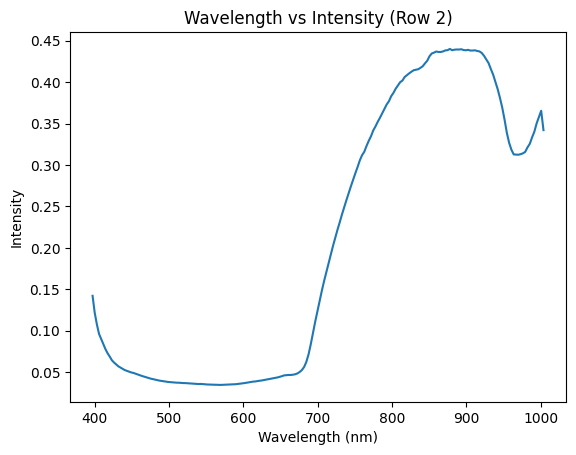

In [25]:
row2 = imgLength_columns_df.iloc[1].values

wavelengths = [float(col.replace('x.', '')) for col in imgLength_columns_df.columns]


plt.plot(wavelengths, row2)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Wavelength vs Intensity (Row 2)")
plt.show()



Wavelength vs Intensity (Row 1 vs Row 2)

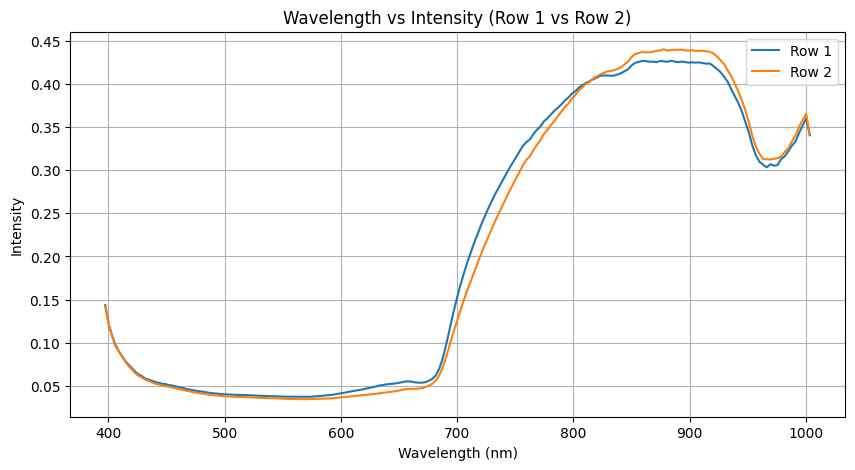

In [26]:
plt.figure(figsize=(10,5))

plt.plot(wavelengths, row1, label="Row 1")
plt.plot(wavelengths, row2, label="Row 2")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Wavelength vs Intensity (Row 1 vs Row 2)")

plt.legend()
plt.grid(True)

plt.show()

Wavelength vs Intensity (First 10 Rows)

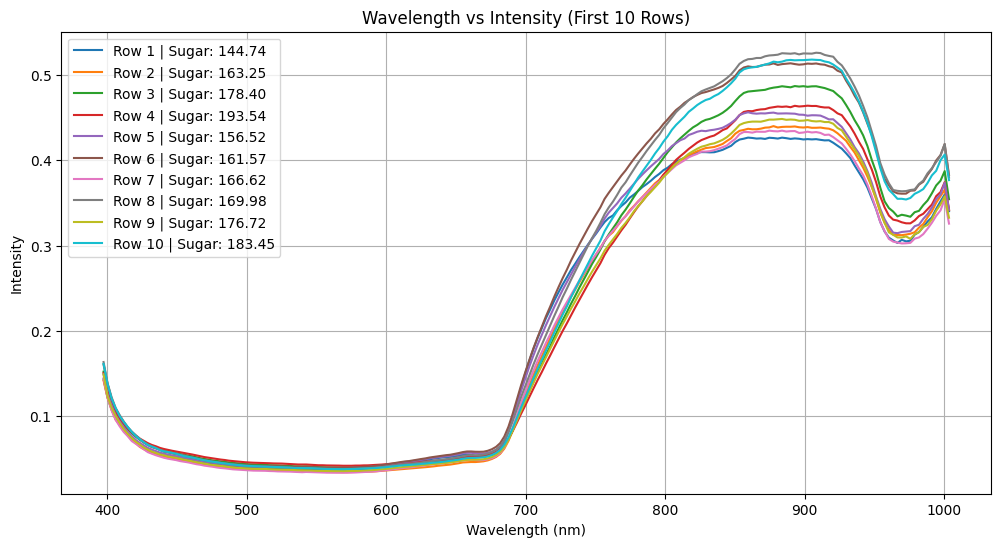

In [27]:
plt.figure(figsize=(12,6))

# Loop through first 10 rows
for i in range(10):
    sugar = df.iloc[i]['Sugar content (g/l)']
    plt.plot(wavelengths,imgLength_columns_df.iloc[i].values, label=f"Row {i+1} | Sugar: {sugar:.2f}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Wavelength vs Intensity (First 10 Rows)")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
for i in range(10):
    row = df.iloc[i]
    print(f"Row {i+1}: {row['Variety']} | Sugar: {row['Sugar content (g/l)']}")

Row 1: SYRAH | Sugar: 144.738
Row 2: SYRAH | Sugar: 163.251
Row 3: SYRAH | Sugar: 178.398
Row 4: SYRAH | Sugar: 193.545
Row 5: SYRAH | Sugar: 156.519
Row 6: SYRAH | Sugar: 161.568
Row 7: SYRAH | Sugar: 166.617
Row 8: SYRAH | Sugar: 169.983
Row 9: SYRAH | Sugar: 176.715
Row 10: SYRAH | Sugar: 183.447


"Wavelength vs Intensity (10 -20 Rows)

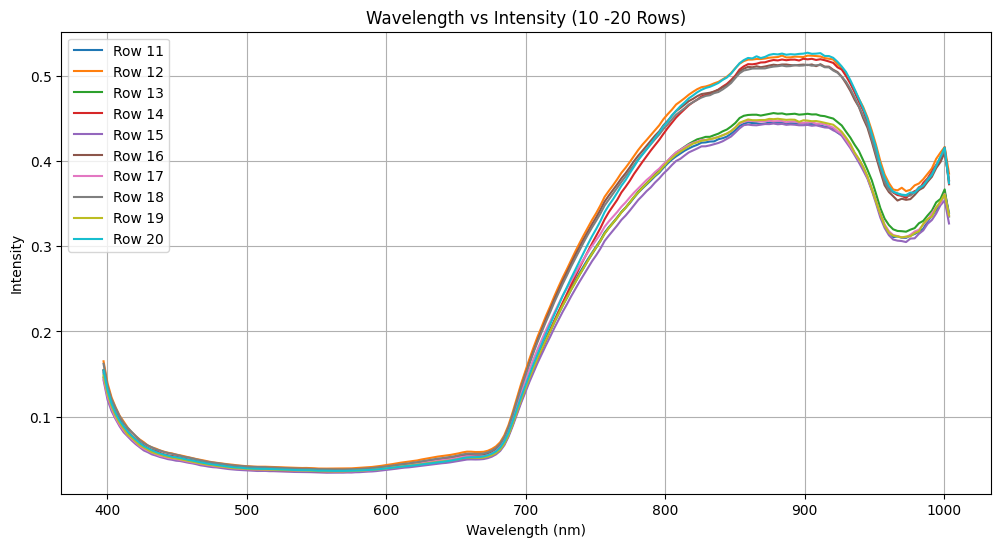

In [29]:
plt.figure(figsize=(12,6))

for i in range(10,20):
    plt.plot(wavelengths,imgLength_columns_df.iloc[i].values, label=f"Row {i+1}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Wavelength vs Intensity (10 -20 Rows)")
plt.legend()
plt.grid(True)

plt.show()

In [30]:
for i in range(10, 20):
    row = df.iloc[i]
    print(f"Row {i+1}: {row['Variety']} | Sugar: {row['Sugar content (g/l)']}")

Row 11: SYRAH | Sugar: 161.568
Row 12: SYRAH | Sugar: 164.934
Row 13: SYRAH | Sugar: 168.3
Row 14: SYRAH | Sugar: 175.032
Row 15: SYRAH | Sugar: 168.3
Row 16: SYRAH | Sugar: 158.202
Row 17: SYRAH | Sugar: 159.885
Row 18: SYRAH | Sugar: 164.934
Row 19: SYRAH | Sugar: 159.885
Row 20: SYRAH | Sugar: 169.983


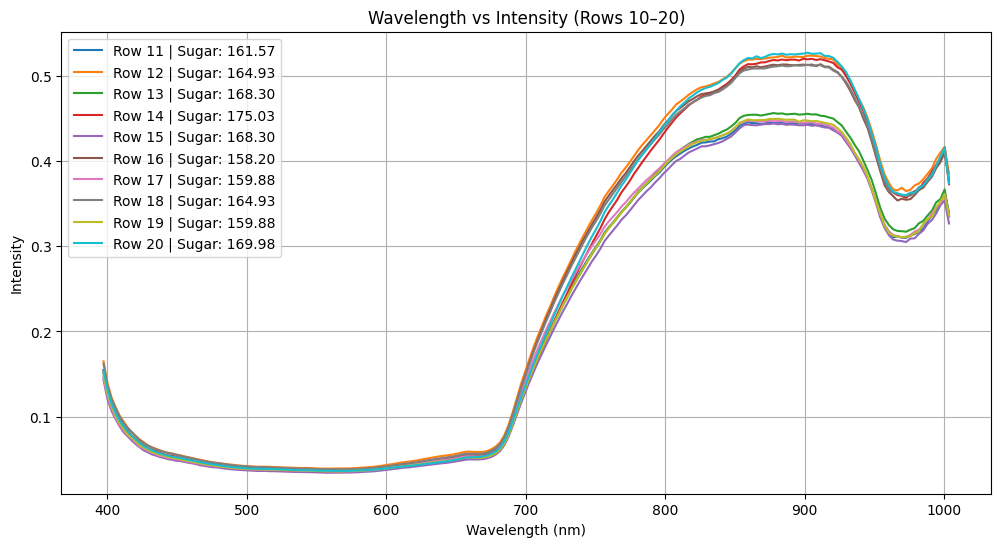

In [31]:
plt.figure(figsize=(12,6))

for i in range(10, 20):
    intensity = imgLength_columns_df.iloc[i].values
    sugar = df.iloc[i]['Sugar content (g/l)']   # get sugar value

    plt.plot(wavelengths, intensity,
             label=f"Row {i+1} | Sugar: {sugar:.2f}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Wavelength vs Intensity (Rows 10–20)")
plt.legend()
plt.grid(True)

plt.show()

sort the dataframe in ascending order based on sugar content

In [32]:
df_sorted_syrah = df_syrah.sort_values(by='Sugar content (g/l)', ascending=True).reset_index(drop=True)
df_sorted_syrah.head()

,Unnamed: 0,Variety,Sugar content (g/l),x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
0,29,SYRAH,122.859,0.151433,0.126406,0.111586,0.099987,0.091781,0.085011,0.078140,...,0.331652,0.333109,0.338688,0.341670,0.347745,0.359777,0.363415,0.374686,0.382282,0.353665
1,30,SYRAH,131.274,0.165220,0.140338,0.121942,0.110728,0.100978,0.093026,0.086502,...,0.380268,0.380434,0.387491,0.390448,0.397260,0.404332,0.415997,0.421783,0.434301,0.397709
2,65,SYRAH,131.274,0.157406,0.134111,0.119064,0.108469,0.099920,0.093009,0.086958,...,0.375193,0.376570,0.379445,0.386981,0.393617,0.403395,0.407911,0.422126,0.429000,0.389656
3,1,SYRAH,144.738,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,...,0.305829,0.312961,0.315948,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379
4,27,SYRAH,146.421,0.146057,0.126241,0.112067,0.100448,0.092032,0.085369,0.078591,...,0.314764,0.318998,0.323821,0.328810,0.334974,0.341484,0.350617,0.357251,0.362332,0.337711


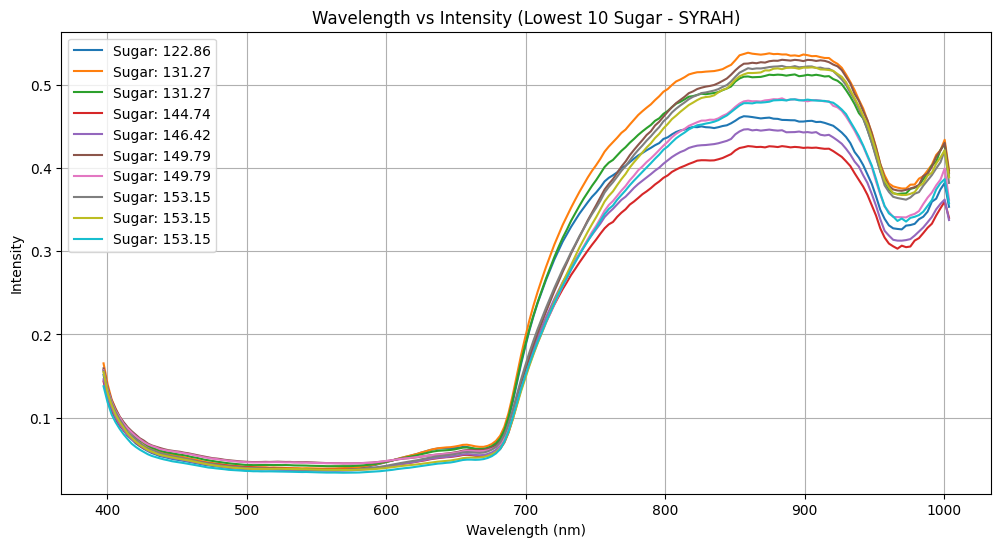

In [33]:
spectral_cols = df.columns[3:]

plt.figure(figsize=(12,6))

for i in range(10):
    row = df_sorted_syrah.iloc[i]

    intensity = row[spectral_cols].values   # only spectral data
    sugar = row['Sugar content (g/l)']

    plt.plot(wavelengths, intensity,
             label=f"Sugar: {sugar:.2f}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Wavelength vs Intensity (Lowest 10 Sugar - SYRAH)")
plt.legend()
plt.grid(True)

plt.show()

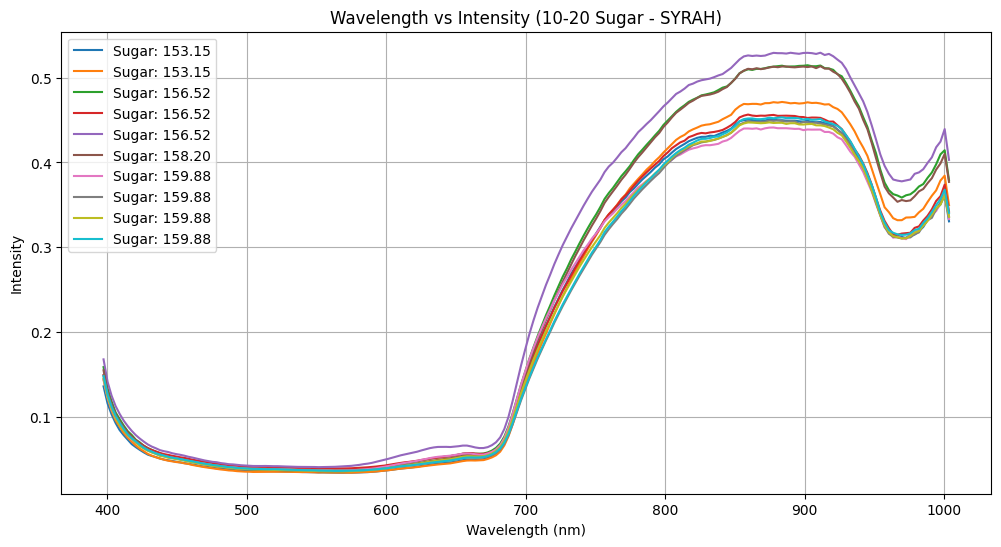

In [34]:

plt.figure(figsize=(12,6))

for i in range(10,20):
    row = df_sorted_syrah.iloc[i]

    intensity = row[spectral_cols].values   # only spectral data
    sugar = row['Sugar content (g/l)']

    plt.plot(wavelengths, intensity,
             label=f"Sugar: {sugar:.2f}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Wavelength vs Intensity (10-20 Sugar - SYRAH)")
plt.legend()
plt.grid(True)

plt.show()

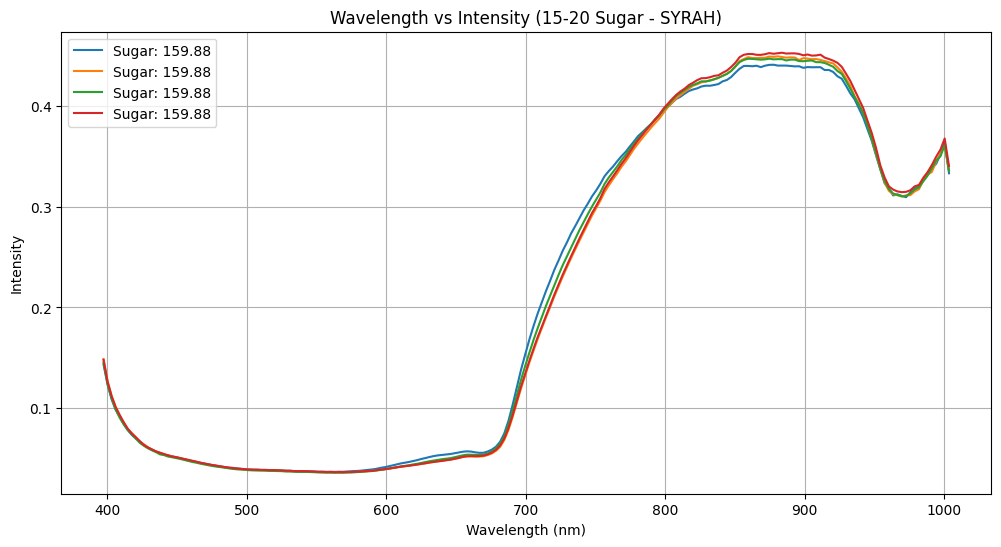

In [35]:

plt.figure(figsize=(12,6))

for i in range(16,20):
    row = df_sorted_syrah.iloc[i]

    intensity = row[spectral_cols].values   # only spectral data
    sugar = row['Sugar content (g/l)']

    plt.plot(wavelengths, intensity,
             label=f"Sugar: {sugar:.2f}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Wavelength vs Intensity (15-20 Sugar - SYRAH)")
plt.legend()
plt.grid(True)

plt.show()

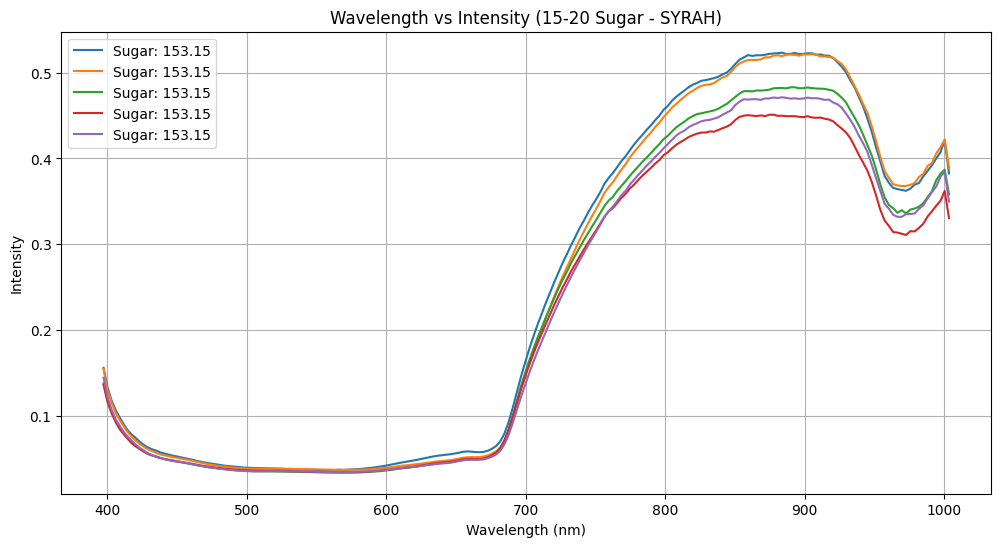

In [36]:
plt.figure(figsize=(12,6))

for i in range(7,12):
    row = df_sorted_syrah.iloc[i]

    intensity = row[spectral_cols].values   # only spectral data
    sugar = row['Sugar content (g/l)']

    plt.plot(wavelengths, intensity,
             label=f"Sugar: {sugar:.2f}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Wavelength vs Intensity (15-20 Sugar - SYRAH)")
plt.legend()
plt.grid(True)


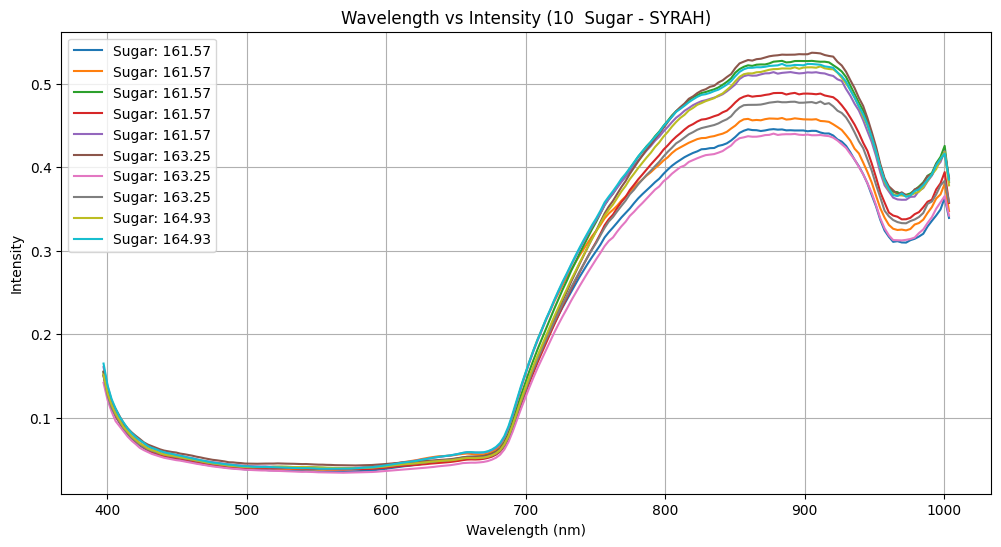

In [37]:

plt.figure(figsize=(12,6))

for i in range(20,30):
    row = df_sorted_syrah.iloc[i]

    intensity = row[spectral_cols].values   # only spectral data
    sugar = row['Sugar content (g/l)']

    plt.plot(wavelengths, intensity,
             label=f"Sugar: {sugar:.2f}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.title("Wavelength vs Intensity (10  Sugar - SYRAH)")
plt.legend()
plt.grid(True)

plt.show()

In [38]:
for i in range(50):
    sugar = df_sorted_syrah.iloc[i]['Sugar content (g/l)']
    print(f"Row { i+1 }  → Sugar: {sugar:.2f}")

Row 1  → Sugar: 122.86
Row 2  → Sugar: 131.27
Row 3  → Sugar: 131.27
Row 4  → Sugar: 144.74
Row 5  → Sugar: 146.42
Row 6  → Sugar: 149.79
Row 7  → Sugar: 149.79
Row 8  → Sugar: 153.15
Row 9  → Sugar: 153.15
Row 10  → Sugar: 153.15
Row 11  → Sugar: 153.15
Row 12  → Sugar: 153.15
Row 13  → Sugar: 156.52
Row 14  → Sugar: 156.52
Row 15  → Sugar: 156.52
Row 16  → Sugar: 158.20
Row 17  → Sugar: 159.88
Row 18  → Sugar: 159.88
Row 19  → Sugar: 159.88
Row 20  → Sugar: 159.88
Row 21  → Sugar: 161.57
Row 22  → Sugar: 161.57
Row 23  → Sugar: 161.57
Row 24  → Sugar: 161.57
Row 25  → Sugar: 161.57
Row 26  → Sugar: 163.25
Row 27  → Sugar: 163.25
Row 28  → Sugar: 163.25
Row 29  → Sugar: 164.93
Row 30  → Sugar: 164.93
Row 31  → Sugar: 164.93
Row 32  → Sugar: 164.93
Row 33  → Sugar: 166.62
Row 34  → Sugar: 168.30
Row 35  → Sugar: 168.30
Row 36  → Sugar: 168.30
Row 37  → Sugar: 168.30
Row 38  → Sugar: 169.98
Row 39  → Sugar: 169.98
Row 40  → Sugar: 169.98
Row 41  → Sugar: 169.98
Row 42  → Sugar: 169.98
R

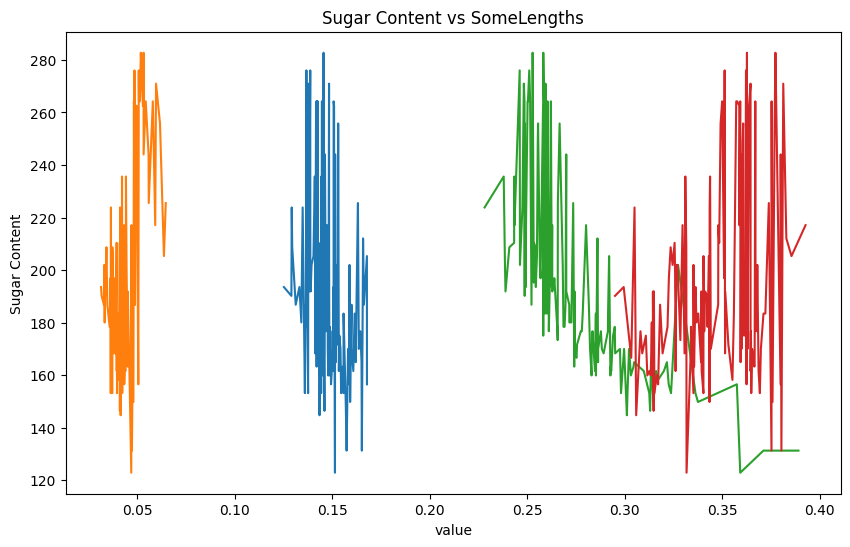

In [39]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="x.397.32", y="Sugar content (g/l)", data=df_syrah)
sns.lineplot(x="x.601.55", y="Sugar content (g/l)", data=df_syrah)
sns.lineplot(x="x.744.53", y="Sugar content (g/l)", data=df_syrah)
sns.lineplot(x="x.975.79", y="Sugar content (g/l)", data=df_syrah)
plt.title("Sugar Content vs SomeLengths")
plt.xlabel("value")
plt.ylabel("Sugar Content")
plt.show()

##PCA

In [66]:
spectral_cols = df.columns[3:]   # skip Unnamed, Variety, Sugar
X = df[spectral_cols].values

In [67]:
# Befor applying the next steps of PCA the features should be first normalized to have zero mean

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [68]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)   # reduce to 2D
X_pca = pca.fit_transform(X_scaled)

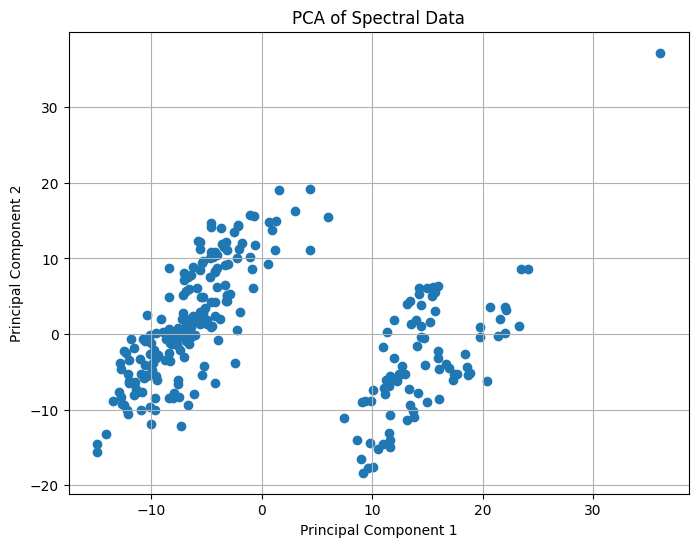

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Spectral Data")

plt.grid(True)
plt.show()

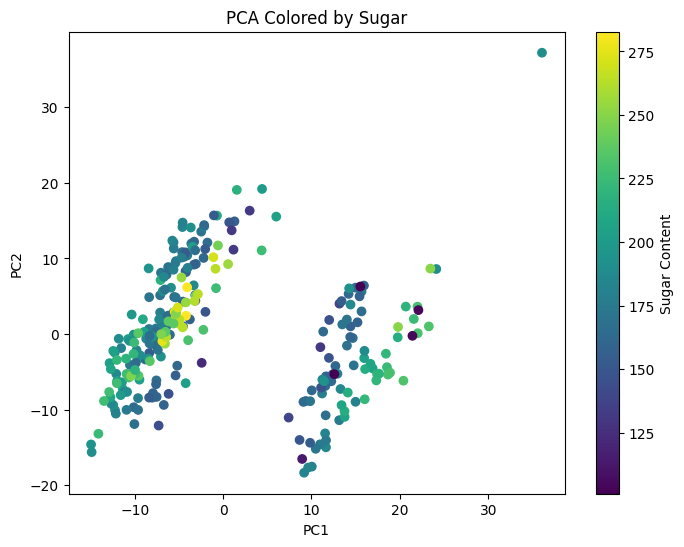

In [70]:
sugar = df['Sugar content (g/l)']

plt.figure(figsize=(8,6))

scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=sugar)

plt.colorbar(scatter, label="Sugar Content")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Colored by Sugar")

plt.show()

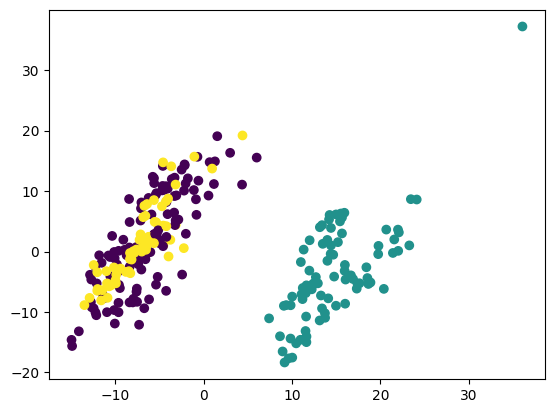

In [71]:
import pandas as pd

variety_labels = pd.factorize(df['Variety'])[0]

plt.scatter(X_pca[:,0], X_pca[:,1], c=variety_labels)

In [72]:
print(pca.explained_variance_ratio_)

[0.56167286 0.31687108]


In [73]:
pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(274, 3)


## Data Preprocessing

In [97]:
x = df.drop(['Sugar content (g/l)', 'Unnamed: 0'], axis=1)
x.head()

,Variety,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
0,SYRAH,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,0.074226,0.070202,...,0.305829,0.312961,0.315948,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379
1,SYRAH,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,0.072666,0.068645,...,0.314022,0.315759,0.321164,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064
2,SYRAH,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,0.080265,0.076254,...,0.333914,0.339243,0.340825,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477
3,SYRAH,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,0.081407,0.077536,...,0.326189,0.329614,0.334720,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181
4,SYRAH,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,0.076906,0.072377,...,0.317075,0.322848,0.324559,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115


Target value

In [98]:
y = df['Sugar content (g/l)']
y.head()

,Sugar content (g/l)
0,144.738
1,163.251
2,178.398
3,193.545
4,156.519


informations about dataframe x

In [99]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Columns: 205 entries, Variety to x.1003.5
dtypes: float64(204), object(1)
memory usage: 439.0+ KB


In [100]:
df.dtypes

,0
Unnamed: 0,int64
Variety,object
Sugar content (g/l),float64
x.397.32,float64
x.400.2,float64
...,...
x.991.22,float64
x.994.31,float64
x.997.4,float64
x.1000.4,float64


In [101]:
x.describe()

,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,x.423.29,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
count,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,...,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000
mean,0.147450,0.126824,0.113056,0.103056,0.095712,0.089099,0.083551,0.078915,0.074883,0.071322,...,0.337773,0.339957,0.342534,0.347161,0.352931,0.359201,0.367682,0.376219,0.385542,0.354093
std,0.009274,0.008172,0.007735,0.007498,0.007322,0.007222,0.007100,0.007037,0.007012,0.006902,...,0.024806,0.024788,0.024987,0.025082,0.025484,0.025685,0.026270,0.026842,0.027109,0.022379
min,0.125258,0.104410,0.093144,0.083413,0.076369,0.070179,0.065280,0.061012,0.057939,0.054886,...,0.283710,0.286194,0.288008,0.294671,0.299517,0.305934,0.311395,0.321888,0.327541,0.308980
25%,0.142021,0.122035,0.108329,0.098554,0.091625,0.084906,0.079497,0.074697,0.070772,0.067134,...,0.318309,0.321428,0.322925,0.328132,0.333237,0.340242,0.348174,0.355489,0.365295,0.336077
50%,0.147429,0.126872,0.113127,0.103141,0.095519,0.088523,0.082944,0.078278,0.074225,0.070513,...,0.337588,0.339892,0.341410,0.346318,0.352364,0.359773,0.366964,0.375281,0.385303,0.352462
75%,0.152870,0.130762,0.116908,0.107201,0.099601,0.092887,0.087379,0.082624,0.078324,0.074677,...,0.356335,0.358440,0.361054,0.366368,0.370812,0.376287,0.386984,0.394249,0.405046,0.369167
max,0.187758,0.165932,0.151804,0.140971,0.131698,0.124344,0.119093,0.112938,0.108828,0.104071,...,0.426330,0.432944,0.434410,0.443655,0.452067,0.460728,0.466456,0.481884,0.488991,0.441394


Check for null cells

In [102]:
x.isnull().sum()

,0
Variety,0
x.397.32,0
x.400.2,0
x.403.09,0
x.405.97,0
...,...
x.991.22,0
x.994.31,0
x.997.4,0
x.1000.4,0


In [103]:
df.isnull().values.any()

np.False_

One hot encoding categorical data

In [105]:
df_Hot = pd.get_dummies(x, columns=['Variety'])
df_Hot.head()

,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,x.423.29,...,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5,Variety_FER,Variety_MAUZAC,Variety_SYRAH
0,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,0.074226,0.070202,0.066113,...,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379,False,False,True
1,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,0.072666,0.068645,0.064228,...,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064,False,False,True
2,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,0.080265,0.076254,0.072553,...,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477,False,False,True
3,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,0.081407,0.077536,0.073961,...,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181,False,False,True
4,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,0.076906,0.072377,0.068974,...,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115,False,False,True


Splitting the dataset

In [106]:
from sklearn.model_selection import train_test_split

x_train,x_,y_train,y_=train_test_split(df_Hot,y,test_size=0.4,random_state=RANDOM_STATE)
x_cv,x_test,y_cv,y_test=train_test_split(x_,y_,test_size=0.5,random_state=RANDOM_STATE)
del x_,y_

In [107]:
x_train.head()

,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,x.423.29,...,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5,Variety_FER,Variety_MAUZAC,Variety_SYRAH
244,0.137363,0.118885,0.106424,0.096758,0.088888,0.083199,0.077651,0.073409,0.069367,0.065967,...,0.345027,0.349122,0.357528,0.367607,0.374689,0.379399,0.345001,True,False,False
41,0.150717,0.127845,0.113801,0.101908,0.094539,0.086848,0.081153,0.076322,0.071769,0.068107,...,0.352013,0.358644,0.361020,0.373337,0.380665,0.394069,0.357177,False,False,True
39,0.166267,0.141713,0.127785,0.116219,0.107672,0.100852,0.093157,0.088847,0.083758,0.080123,...,0.358338,0.367854,0.372276,0.384501,0.392423,0.400444,0.371516,False,False,True
125,0.134881,0.117412,0.104074,0.095686,0.089464,0.082524,0.078181,0.073844,0.069631,0.066541,...,0.353425,0.356864,0.362661,0.367387,0.376530,0.383219,0.347387,False,False,True
269,0.131722,0.113796,0.103341,0.095964,0.089877,0.085319,0.080727,0.075664,0.072211,0.069393,...,0.340073,0.343939,0.350302,0.356119,0.365598,0.373545,0.341245,True,False,False


In [108]:
x_cv.head()

,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,x.423.29,...,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5,Variety_FER,Variety_MAUZAC,Variety_SYRAH
168,0.151545,0.129878,0.116833,0.107131,0.099860,0.093377,0.087807,0.082670,0.078885,0.075408,...,0.391210,0.399362,0.401650,0.413682,0.422616,0.431251,0.390199,True,False,False
45,0.145533,0.124821,0.110009,0.100097,0.091272,0.084262,0.078740,0.074664,0.070304,0.066394,...,0.353027,0.359389,0.368255,0.372962,0.385238,0.393000,0.359378,False,False,True
122,0.129107,0.108298,0.095313,0.085951,0.078123,0.072491,0.067113,0.063307,0.058968,0.055308,...,0.303064,0.310515,0.315913,0.324192,0.331515,0.341979,0.315795,False,False,True
50,0.155472,0.134759,0.120205,0.110785,0.102057,0.093221,0.087455,0.082668,0.078588,0.074876,...,0.380864,0.389461,0.390733,0.403438,0.409102,0.417782,0.387287,False,False,True
211,0.150794,0.127082,0.111800,0.101156,0.094241,0.087494,0.081852,0.077205,0.073500,0.069480,...,0.317119,0.323491,0.327018,0.336189,0.349748,0.355115,0.331347,False,True,False


In [109]:
x_test.head()

,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,x.423.29,...,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5,Variety_FER,Variety_MAUZAC,Variety_SYRAH
21,0.164454,0.140551,0.123630,0.110973,0.102326,0.095661,0.088223,0.082962,0.078163,0.073984,...,0.373458,0.379744,0.388055,0.395132,0.407582,0.416038,0.383451,False,False,True
130,0.141091,0.123679,0.110638,0.101413,0.094087,0.088310,0.082550,0.078217,0.073468,0.070425,...,0.341423,0.346247,0.349396,0.358390,0.362780,0.376600,0.346457,False,False,True
191,0.149729,0.129002,0.117379,0.108232,0.100629,0.093196,0.087876,0.082385,0.078310,0.075244,...,0.356373,0.365331,0.368334,0.380782,0.389891,0.399313,0.367088,True,False,False
150,0.152936,0.133707,0.119018,0.107782,0.098625,0.092366,0.086864,0.081931,0.077745,0.073029,...,0.356674,0.359985,0.370611,0.378775,0.386267,0.394345,0.365083,False,True,False
109,0.138811,0.118400,0.102731,0.092487,0.086225,0.080630,0.075013,0.070197,0.066543,0.062906,...,0.337263,0.336853,0.344176,0.352923,0.356932,0.369526,0.335482,False,False,True


In [110]:
y_train.head()

,Sugar content (g/l)
244,190.179
41,161.568
39,186.813
125,223.839
269,218.790


In [111]:
y_cv.head()

,Sugar content (g/l)
168,191.862
45,176.715
122,190.179
50,163.251
211,213.741


In [112]:
y_test.head()

,Sugar content (g/l)
21,176.715
130,235.620
191,156.519
150,156.519
109,201.960


In [113]:
x_train.isnull().sum()

,0
x.397.32,0
x.400.2,0
x.403.09,0
x.405.97,0
x.408.85,0
...,...
x.1000.4,0
x.1003.5,0
Variety_FER,0
Variety_MAUZAC,0


In [114]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164 entries, 244 to 131
Columns: 207 entries, x.397.32 to Variety_SYRAH
dtypes: bool(3), float64(204)
memory usage: 263.1 KB


##Linear Regression

In [117]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)

x_cv_scaled = scaler.transform(x_cv)
x_test_scaled = scaler.transform(x_test)


In [120]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

print(linear_model)

LinearRegression()


In [121]:
y_hat = linear_model.predict(X_train_scaled)
print(f"Training MSE : {mean_squared_error(y_train,yhat)/2}")

Training MSE : 2.0157710838697868e-23


In [123]:
y_cv_hat = linear_model.predict(x_cv_scaled)
print(f"CV MSE : {mean_squared_error(y_cv,y_cv_hat)/2}")

CV MSE : 1827.154884576698


This is overfitting to the dataset

In [124]:
w_norm = linear_model.coef_
b_norm = linear_model.intercept_
print(f"w = {w_norm}, b = {b_norm}")

w = [ 4.90678579e+01 -2.02014735e+01 -6.49829511e+00  5.35858079e+01
 -1.03160212e+02  6.37235724e+01 -4.00214633e+01  4.69267368e+01
 -2.35026149e+02 -1.05503502e+02  2.38283328e+02 -8.02829233e+01
  1.18916771e+02  5.17400028e+01 -1.06116427e+02 -1.13473907e+02
  3.60761015e+02 -3.00973220e+02 -1.10579181e+02  5.50540171e+02
  8.82258907e+01  2.19347036e+02 -1.24122648e+02 -1.07224503e+02
  5.28064283e+02 -2.97132150e+02 -6.33294428e+02  1.27177916e+02
 -4.25194665e+01  9.04420144e+02 -2.43426994e+02 -5.28322009e+02
 -7.59190831e+02 -6.52915201e+02  7.19040672e+02 -6.08814153e+01
  4.28321170e+02  1.95822844e+01  9.23899174e+02 -1.03941399e+03
  1.05876595e+03 -5.78095980e+02 -1.64299901e+03  1.50401968e+03
  7.71994752e+02  1.72770001e+03 -1.38639605e+03 -1.44967457e+03
 -7.53593928e+02  6.58370217e+02  4.38422998e+02 -2.43593965e+02
  2.74860535e+02  8.06710807e+01  6.72441926e+01  7.81222580e+02
 -3.65535328e+02 -1.03619207e+03  1.00490709e+03 -6.20263926e+01
  8.44085437e+02 -3.4

In [60]:
x_cv_processed.head()

,num__x.397.32,num__x.400.2,num__x.403.09,num__x.405.97,num__x.408.85,num__x.411.74,num__x.414.63,num__x.417.52,num__x.420.4,num__x.423.29,...,num__x.985.05,num__x.988.13,num__x.991.22,num__x.994.31,num__x.997.4,num__x.1000.4,num__x.1003.5,cat__Variety_FER,cat__Variety_MAUZAC,cat__Variety_SYRAH
0,0.393427,0.333227,0.440146,0.490407,0.516901,0.536730,0.543066,0.478152,0.516360,0.534083,...,1.696872,1.755704,1.607572,1.701929,1.664937,1.620764,1.560728,1.0,0.0,0.0
1,-0.245337,-0.268624,-0.415617,-0.411584,-0.612998,-0.667387,-0.674595,-0.601845,-0.649111,-0.706662,...,0.207188,0.222239,0.326746,0.177138,0.302082,0.241205,0.212066,0.0,0.0,1.0
2,-1.990541,-2.235116,-2.258381,-2.225793,-2.342827,-2.222294,-2.236143,-2.134009,-2.188799,-2.232643,...,-1.742093,-1.652756,-1.680735,-1.649076,-1.656769,-1.598905,-1.695042,0.0,0.0,1.0
3,0.810669,0.914079,0.862992,0.959069,0.805899,0.516102,0.495818,0.477978,0.475952,0.460971,...,1.293232,1.375872,1.188844,1.318319,1.172190,1.135012,1.433299,0.0,0.0,1.0
4,0.313656,0.000470,-0.190994,-0.275782,-0.222373,-0.240373,-0.256747,-0.259097,-0.215119,-0.281832,...,-1.193751,-1.154919,-1.254842,-1.199831,-0.991936,-1.125140,-1.014497,0.0,1.0,0.0


In [61]:
X_train_processed_array

array([[-1.11337068, -0.97506134, -0.86512931, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.30548796,  0.09129588,  0.05992847, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.95766203,  1.74175449,  1.81338309, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.52322755,  0.32105327,  0.22490262, ...,  0.        ,
         1.        ,  0.        ],
       [-0.42612097, -0.59611374, -0.8623042 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.3552446 , -0.48612768, -0.289106  , ...,  0.        ,
         0.        ,  1.        ]])

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

LinearRegression()

In [63]:
yhat = linear_model.predict(X_train_processed)

print(f"Training MSE : {mean_squared_error(y_train,yhat)/2}")

Training MSE : 2.0157710838697868e-23


In [64]:
y_cvhat = linear_model.predict(x_cv_processed)

print(f"CV MSE : {mean_squared_error(y_cv,y_cvhat)/2}")

CV MSE : 1821.9446100376592


In [65]:
train_MSES =[]
cv_MSES =[]
models = []
polys = []
scalers = []

for degree in range(1:7):


SyntaxError: invalid syntax (1373974186.py, line 7)

In [ ]:
spectral_cols = df.columns[3:]   # only wavelength columns

X = df[spectral_cols].values
y = df['Sugar content (g/l)'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)   # keep 95% information
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Number of components:", X_train_pca.shape[1])

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_pca, y_train)

In [ ]:
y_pred = model.predict(X_test_pca)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R² Score:", r2)

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sugar")
plt.ylabel("Predicted Sugar")
plt.title("Actual vs Predicted Sugar")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # perfect prediction line

plt.grid(True)
plt.show()

In [ ]:
spectral_cols = df.columns[3:]

X = df[spectral_cols].values
y = df['Sugar content (g/l)'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R² Score:", r2)

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sugar")
plt.ylabel("Predicted Sugar")
plt.title("Actual vs Predicted (Linear Regression)")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.grid(True)
plt.show()